In [1]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction. text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
with zipfile.ZipFile('/content/archive (15).zip', 'r') as zip_ref:
  zip_ref.extractall()

In [3]:
df = pd.read_csv('/content/spotify_millsongdata.csv')

In [4]:
df.shape

(57650, 4)

In [5]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [7]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [8]:
top_artists = df['artist'].value_counts().head(15)
print("\nTop 10 artists:")
print(top_artists)


Top 10 artists:
artist
Donna Summer         191
Gordon Lightfoot     189
Bob Dylan            188
George Strait        188
Loretta Lynn         187
Alabama              187
Cher                 187
Reba Mcentire        187
Chaka Khan           186
Dean Martin          186
Neil Young           185
Hank Williams Jr.    185
Nazareth             184
Indigo Girls         184
America              184
Name: count, dtype: int64


In [9]:
df = df.sample(1500)
df = df.drop('link', axis=1).reset_index(drop=True)

In [10]:
df.shape

(1500, 3)

In [11]:
df.head()

,artist,song,text
0,Dusty Springfield,Make It With You,"Ah, ha, have you ever tried \r\nReally reachi..."
1,Nick Cave,Cannibal's Hymn,You have a heart and I have a key \r\nLie bac...
2,Judas Priest,Dissident Aggressor,Grand canyons of space and time universal \r\...
3,Yellowcard,Surface Of The Sun,This is a story full of restless nights \r\nO...
4,Marilyn Manson,Leave A Scar,Its not like I made myself a list of new and d...


In [12]:
#wordcloud for song lyrics
all_lyrics = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_lyrics)

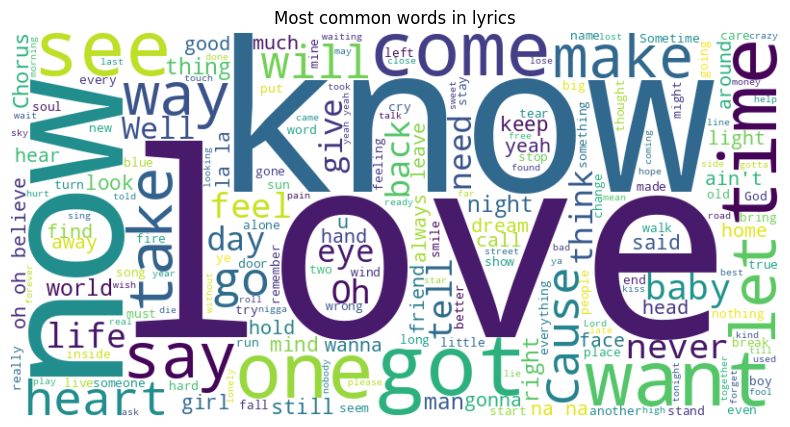

In [13]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most common words in lyrics")
plt.show()

In [14]:
#download nltk data
nltk.download('punkt') #sentence tokenization
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
stop_words = set(stopwords.words('english'))

In [16]:
def preprocess_text(text):
  #remove special characters and numbers
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  #convert to lowercase
  text = text.lower()
  #tokenize and remove stopwords
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  return " ".join(tokens)

In [17]:
#apply preprocessing to lyrics
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [18]:
df.head(6)

,artist,song,text,cleaned_text
0,Dusty Springfield,Make It With You,"Ah, ha, have you ever tried \r\nReally reachi...",ah ha ever tried really reaching side may clim...
1,Nick Cave,Cannibal's Hymn,You have a heart and I have a key \r\nLie bac...,heart key lie back let unlock heathens hang se...
2,Judas Priest,Dissident Aggressor,Grand canyons of space and time universal \r\...,grand canyons space time universal mind subjec...
3,Yellowcard,Surface Of The Sun,This is a story full of restless nights \r\nO...,story full restless nights cause try across de...
4,Marilyn Manson,Leave A Scar,Its not like I made myself a list of new and d...,like made list new different ways murder heart...
5,Devo,Agitated,I grew up in a typical way \r\nSo I keep tryi...,grew typical way keep trying unwind cause im a...


In [19]:
#vectorization with TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [20]:
#compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [21]:
# Recommendation function
def recommend_songs(song_name, cosine_sim=cosine_sim, df=df, top_n=5):

    # Find the index of the song
    idx = df[df['song'].str.lower() == song_name.lower()].index

    if len(idx) == 0:
        return "Song not found in the dataset!"

    idx = idx[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort songs by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Remove the same song itself and get top_n songs
    sim_scores = sim_scores[1:top_n + 1]

    # Get song indices
    song_indices = [i[0] for i in sim_scores]

    # Return recommended songs
    return df[['artist', 'song']].iloc[song_indices]


# Example recommendation
song_name = "To Get Back In"

print(f"\nRecommendations for the song '{song_name}':")
recommendations = recommend_songs(song_name)

print(recommendations)


Recommendations for the song 'To Get Back In':
Song not found in the dataset!
